In [4]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
sns.set_theme()

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to perform t-SNE
from sklearn.manifold import TSNE

# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("Nutrient Composition Dataset.csv")
df.head(), df.columns

(   S.No   Protein       Fat  vitaminC     Fibre  \
 0     1  0.452369  1.170926  1.079271  1.702960   
 1     2  2.321087  0.706856  0.350088  0.658249   
 2     3  0.884554  1.186571  2.428544  1.984562   
 3     4  0.715501  0.577599  0.270925  0.369266   
 4     5  0.132610  0.544521  0.116884  0.557309   
 
                                              Product  
 0  Amaranth leaves, cooked, boiled, drained, with...  
 1                              Bacon and beef sticks  
 2  Apples, frozen, unsweetened, unheated (Include...  
 3         Alcoholic beverage, beer, light, BUD LIGHT  
 4               Alcoholic beverage, daiquiri, canned  ,
 Index(['S.No', 'Protein', 'Fat', 'vitaminC', 'Fibre', 'Product'], dtype='object'))

In [6]:
df2 = df.drop(columns=["S.No"])
q1 = df2["Protein"].quantile(0.25)
q3 = df2["Protein"].quantile(0.75)
iqr = q3 - q1
q1, q3, iqr


(0.43585321625, 1.29510584875, 0.8592526325000001)

In [8]:
df['Fat'].skew()

0.8382541780997608

The Fat variable has a positive skew (skewness ≈ +0.84), which means it is right-skewed, not left-skewed.

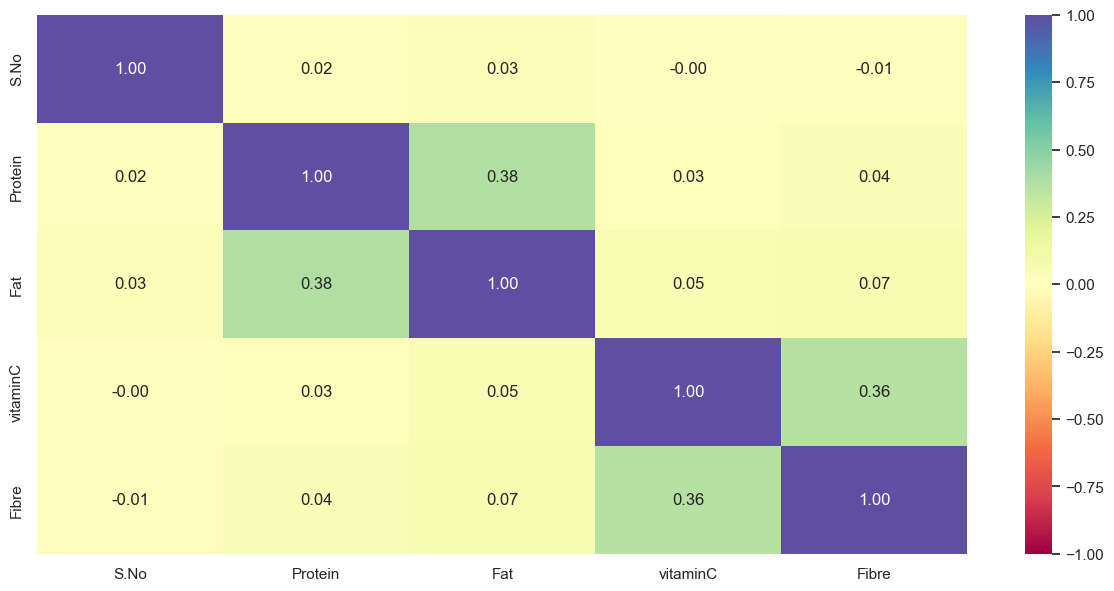

In [9]:
num_col = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 7))
sns.heatmap(df[num_col].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

In [22]:
X = df[['Protein','Fat','vitaminC','Fibre']].sample(200, random_state=1)
Xs = StandardScaler().fit_transform(X)

res=[]
for k in range(2,11):
    km=KMeans(n_clusters=k, random_state=1, n_init=5)
    labels=km.fit_predict(Xs)
    res.append((k, km.inertia_, silhouette_score(Xs, labels)))
res

[(2, 604.3034846273508, 0.2860998938081258),
 (3, 447.77388006148635, 0.28377221192327673),
 (4, 406.1855655649363, 0.22502915281689076),
 (5, 358.8969002435757, 0.21357355267869974),
 (6, 324.45229731282996, 0.23481256625065952),
 (7, 300.3172658000202, 0.19584498064068565),
 (8, 281.823792310775, 0.1987437053995763),
 (9, 257.1996029633942, 0.22110929033554882),
 (10, 244.49768284671833, 0.21217113124746337)]

In [26]:
# fitting K-means model
kmeans = KMeans(n_clusters=3, random_state=1)
kmeans.fit(k_means_df)

KMeans(n_clusters=3, random_state=1)

In [23]:

km = KMeans(n_clusters=3, random_state=1, n_init=10)
labels = km.fit_predict(Xs)

pd.Series(labels).value_counts().sort_index()

0     43
1     57
2    100
Name: count, dtype: int64